<h2 style="text-align: center;"> DETECCIÓN DE OUTLIERS: Medical Insurance Cost Dataset </h2>

<img src="img/ITQ.jpg" width="700">

**Nombre:** *Sebastian Sampedro* <br>
**Fecha:** *9/7/2026* <br>
**Link Github:** "https://github.com/sdsampedro-byte/Python2026ML"

### Paso 1: Importación de Librerias.

In [13]:
# Importación de librerías esenciales para ETL, detección de outliers y Machine Learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Modelos de detección de Outliers (scikit-learn)
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

# Modelado de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

### Paso 2 y 3 : Descarga y Carga del Dataset

In [23]:
# Descarga y carga del dataset 'insurance.csv'
# URL origen: https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction
df = pd.read_csv('medical_insurance.csv')

# Visualizamos las primeras filas para confirmar la carga exitosa
print("Dataset cargado exitosamente")
df.head()

Dataset cargado exitosamente


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


### Paso 4: Realizar una exploración inicial del dataset utilizando:
•	head() <br>
•	tail() <br>
•	info() <br>
•	shape <br>
•	describe() 


In [18]:
# Mostramos las primeras 5 filas del dataset para entender la estructura y formato de los datos
print("Primeras filas del dataset (head):")
df.head()

Primeras filas del dataset (head):


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [35]:
# Mostramos las últimas 5 filas del dataset para verificar cómo terminan los registros
print("Últimas filas del dataset (tail):")
df.tail()

Últimas filas del dataset (tail):


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,0,1,0,0,0,0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,0,1,0,1,0,0,0,0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,0,1,0,0,2,2,1,0,0
99999,15796,44,Female,South,Rural,43700.0,Some College,Married,Employed,2,...,0,0,0,0,0,1,1,1,0,0


In [34]:
# Obtenemos información técnica de las columnas, tipos de datos (int, float, object) y valores no nulos
print("Información general del dataset (info):")
df.info()

Información general del dataset (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker             

In [33]:
# Mostramos las dimensiones totales del dataset en formato (filas, columnas)
print("Dimensiones del dataset (shape):")
df.shape

Dimensiones del dataset (shape):


(100000, 54)

In [32]:
# Generamos un resumen estadístico de las variables numéricas (conteo, media, desviación estándar, min, max, cuartiles)
print("Resumen estadístico (describe):")
df.describe()

Resumen estadístico (describe):


,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


### Paso 5: Identificar:
•	Valores nulos. <br>
•	Registros duplicados. <br>
•	Tipos de datos. 


In [26]:
# 1. Identificar la cantidad de valores nulos presentes en cada columna
print("Valores nulos por columna:")
df.isnull().sum()

Valores nulos por columna:


person_id                          0
age                                0
sex                                0
region                             0
urban_rural                        0
income                             0
education                          0
marital_status                     0
employment_status                  0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
alcohol_freq                   30083
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                              0
policy_term_years                  0
p

In [30]:
# 2. Identificar la cantidad total de registros duplicados en el dataset
print("Total de registros duplicados:")
print(df.duplicated().sum())

Total de registros duplicados:
0


In [31]:
# 3. Identificar el tipo de dato (int, float, object) asociado a cada columna
print("Tipos de datos por columna:")
df.dtypes

Tipos de datos por columna:


person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible                       int64
copay                    

### Paso 6: Seleccionar únicamente las variables numéricas


In [40]:
# Utilizamos el método select_dtypes para filtrar y mantener solo las columnas con datos numéricos (enteros y flotantes)
df_numeric = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32'])

# Mostramos una lista con los nombres de las columnas numéricas seleccionadas
print("Variables numéricas seleccionadas:")
print(df_numeric.columns.tolist())

# Verificamos las nuevas dimensiones del dataset para confirmar que las categóricas fueron excluidas
print(f"Nuevas dimensiones del dataset: {df_numeric.shape}")

Variables numéricas seleccionadas:
['person_id', 'age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']
Nuevas dimensiones del dataset: (100000, 44)


### Paso 7: Generar Boxplots para cada variable numérica

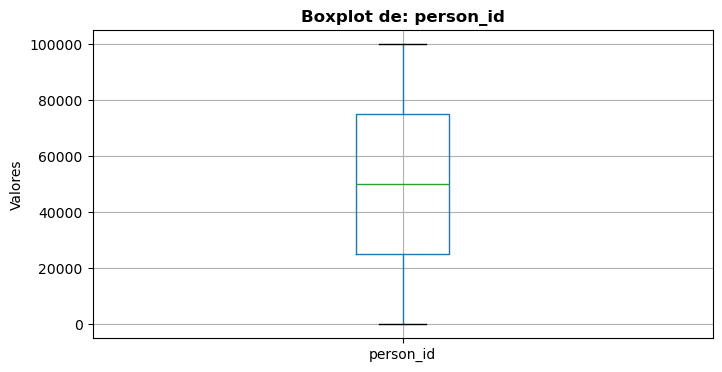

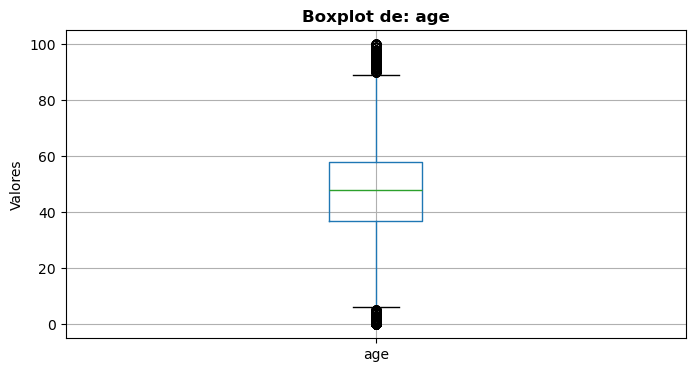

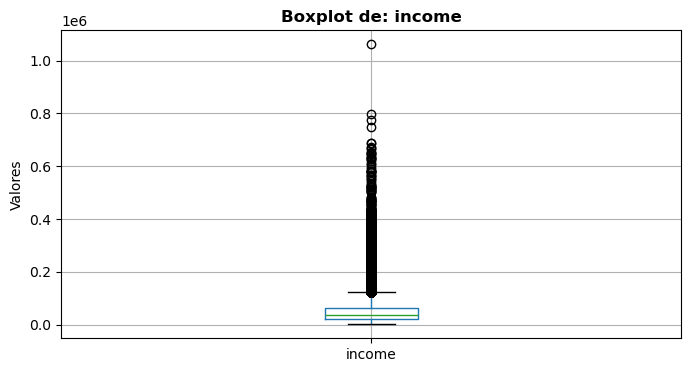

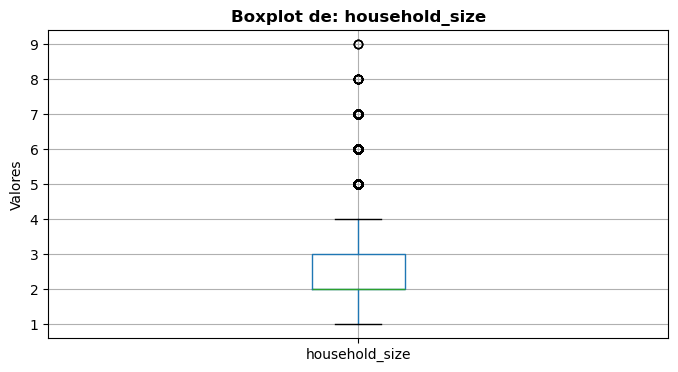

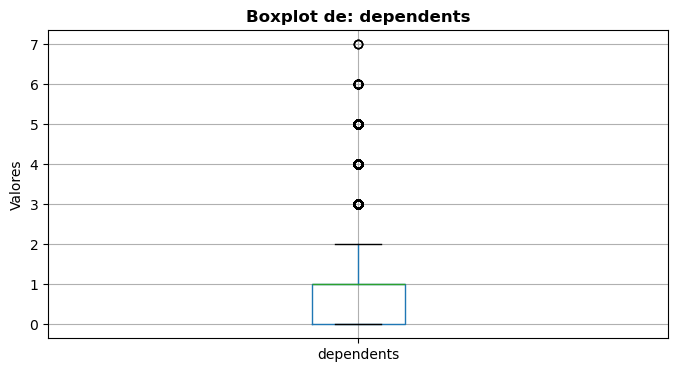

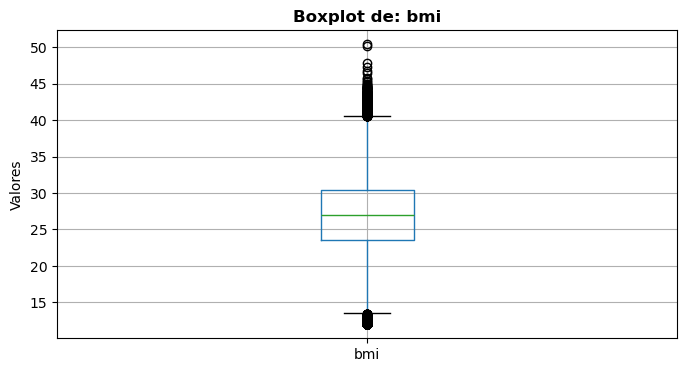

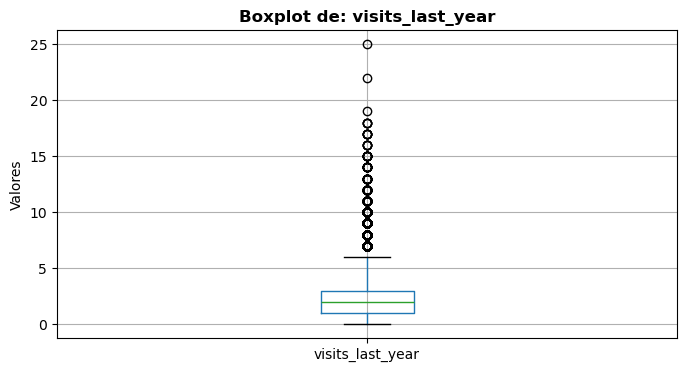

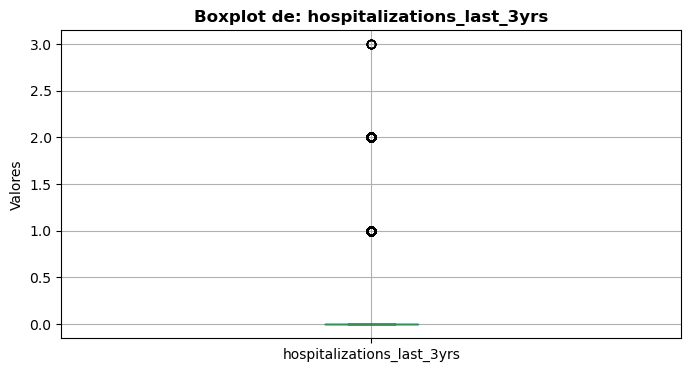

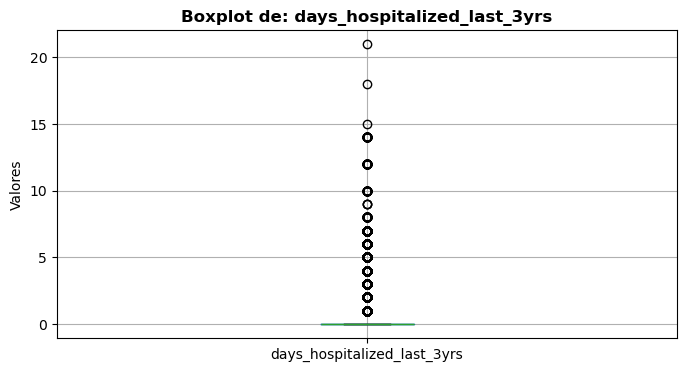

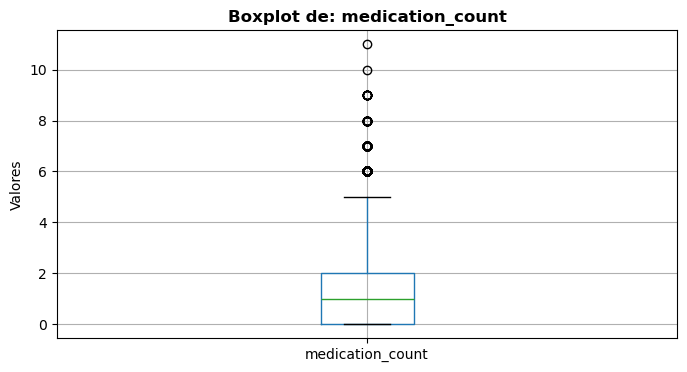

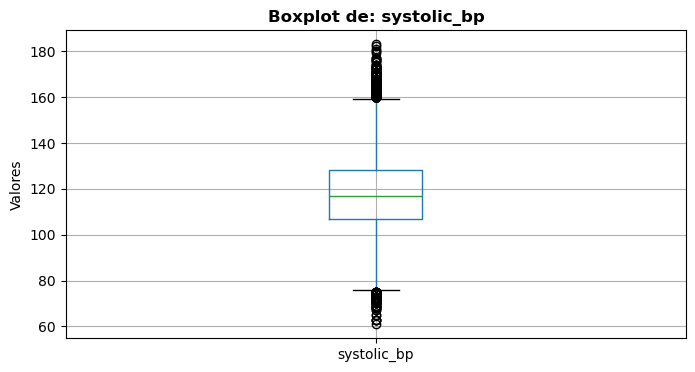

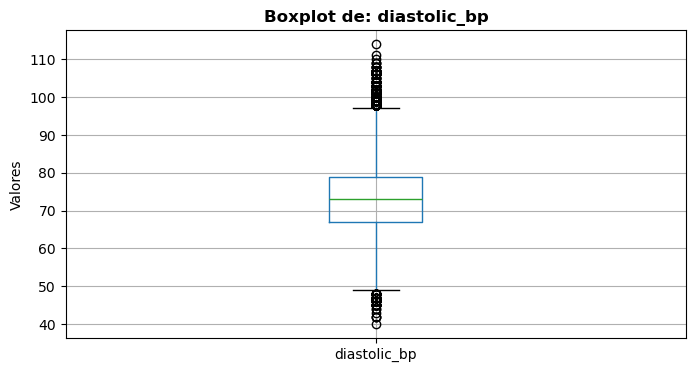

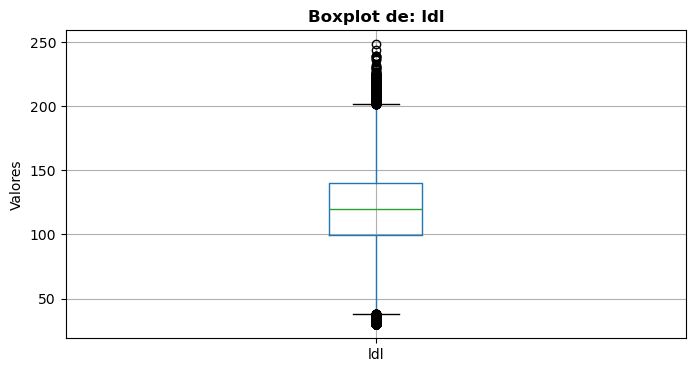

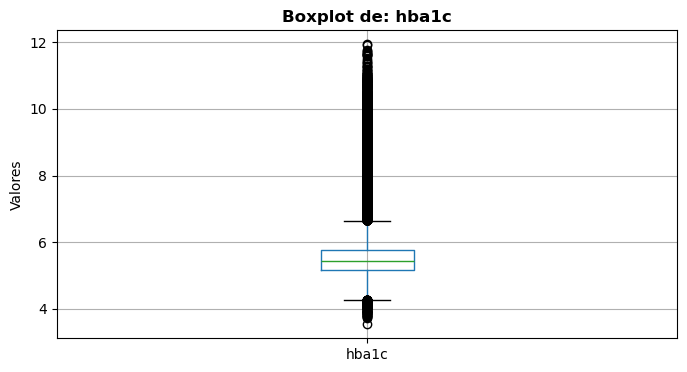

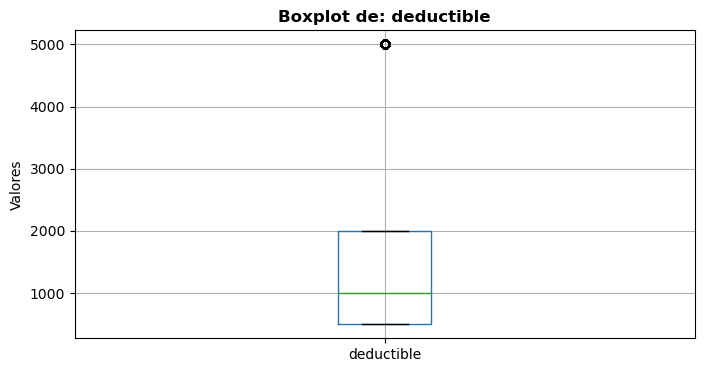

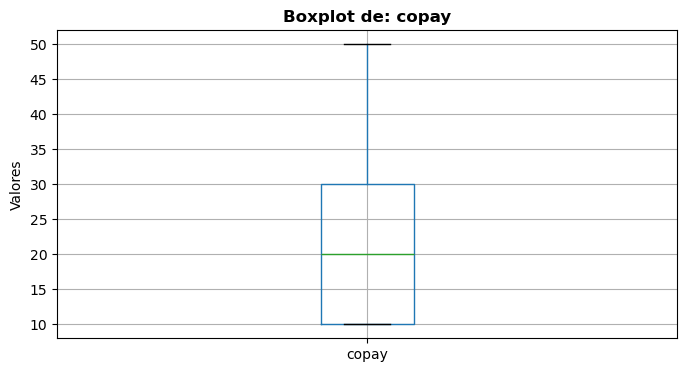

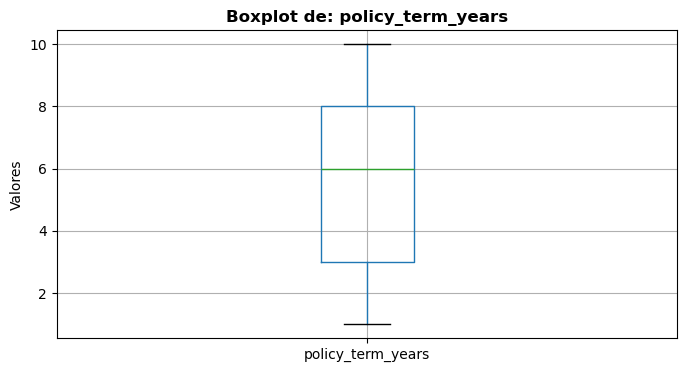

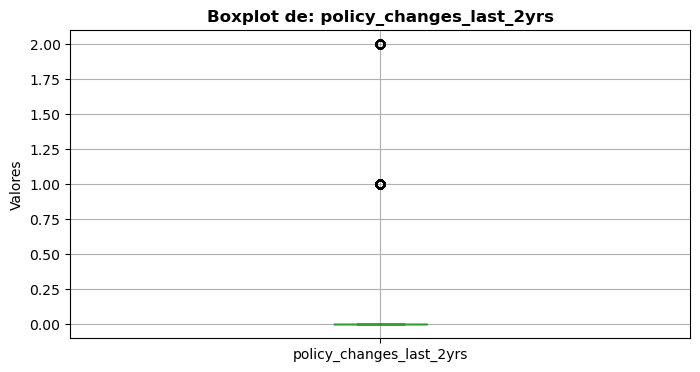

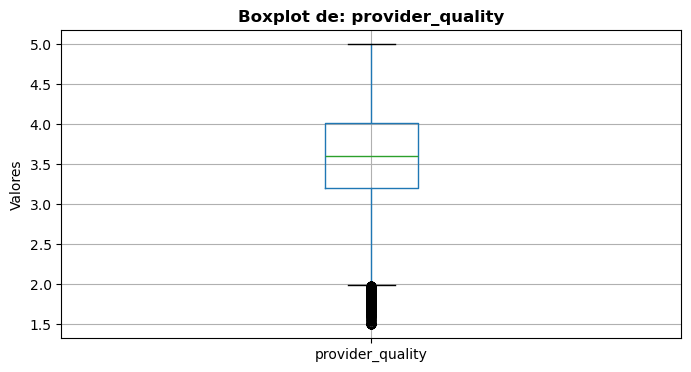

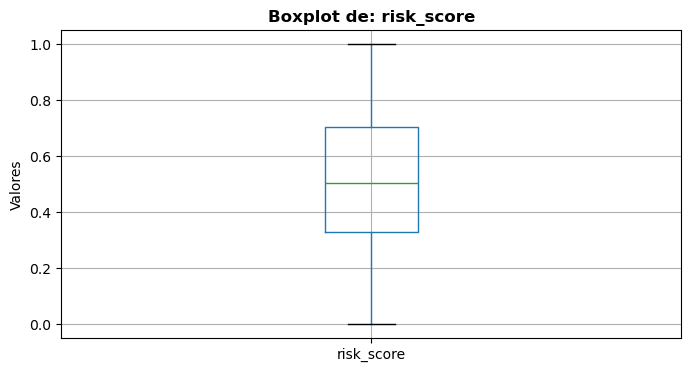

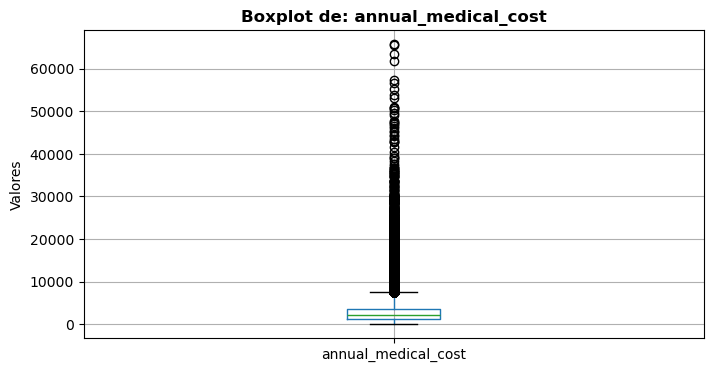

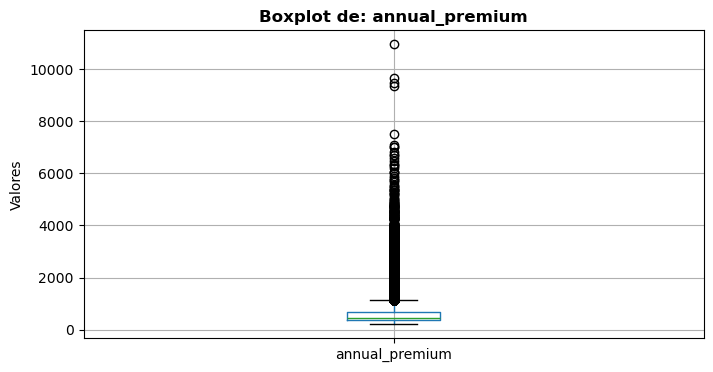

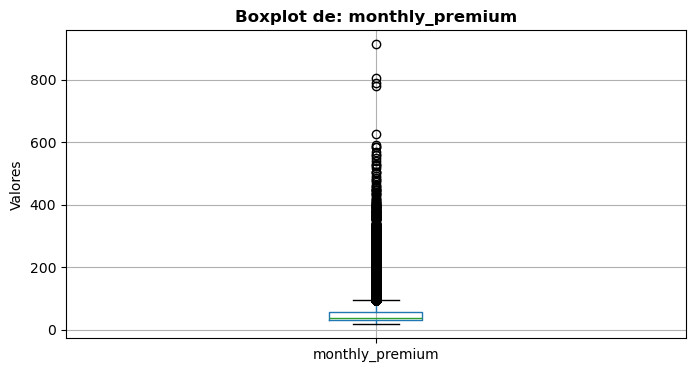

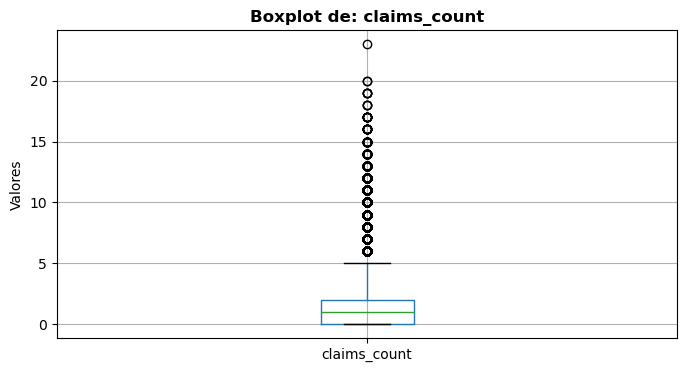

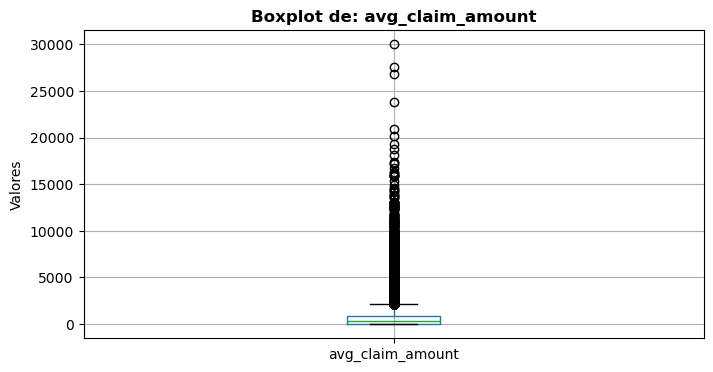

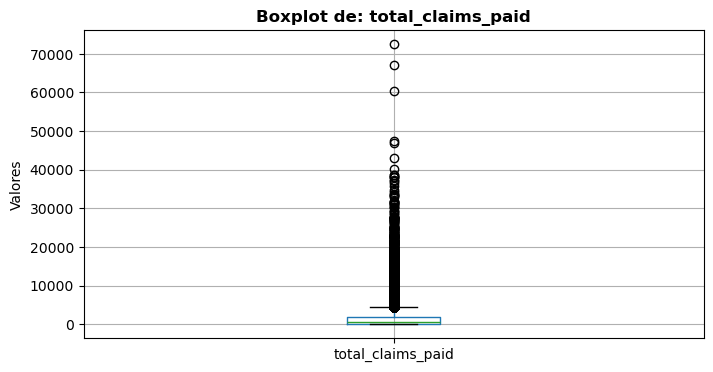

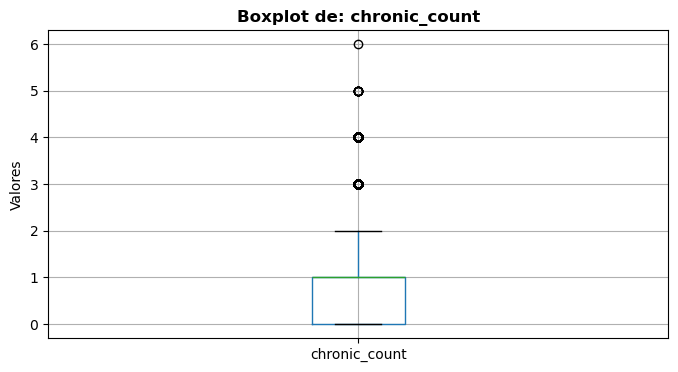

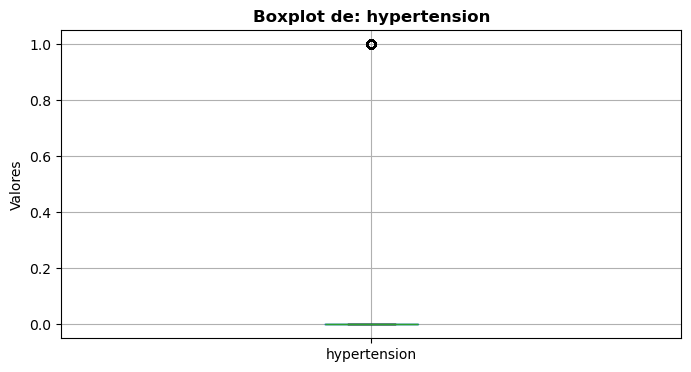

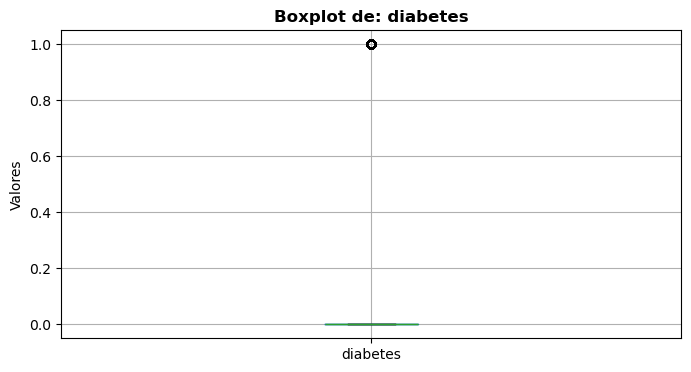

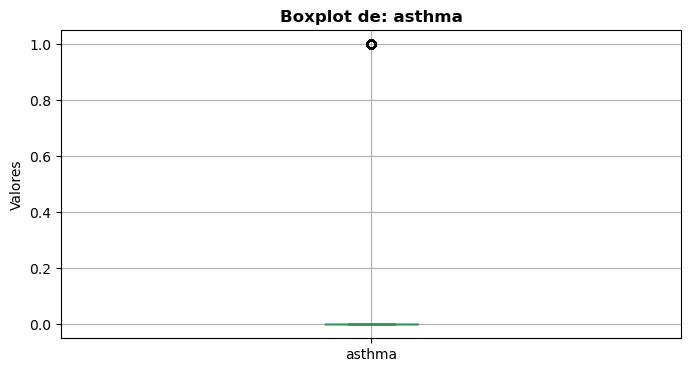

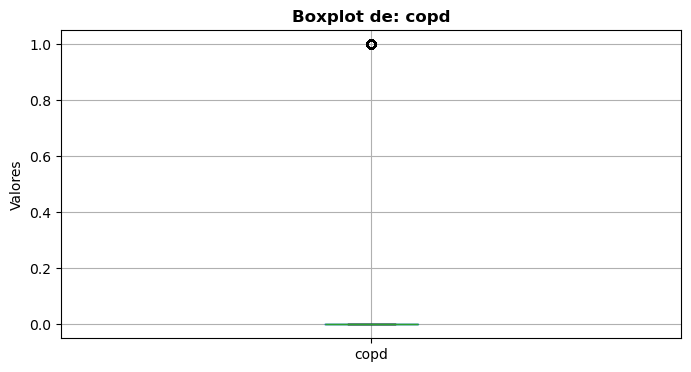

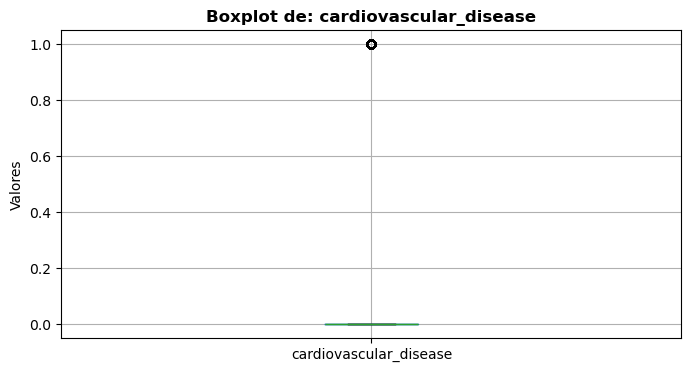

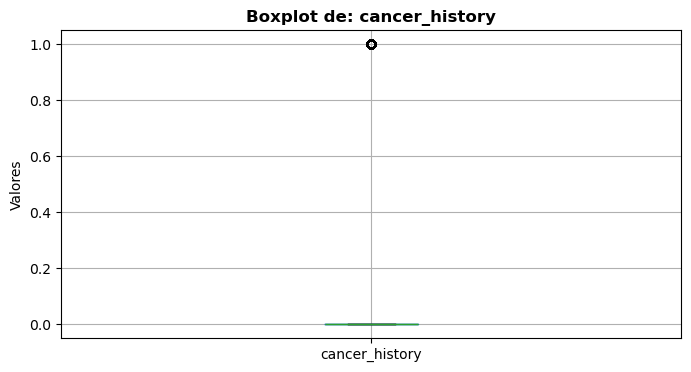

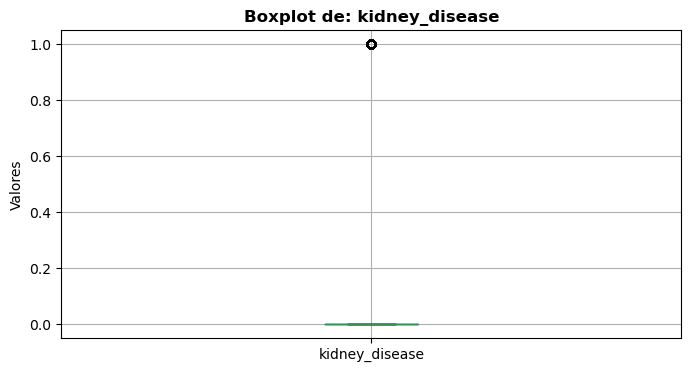

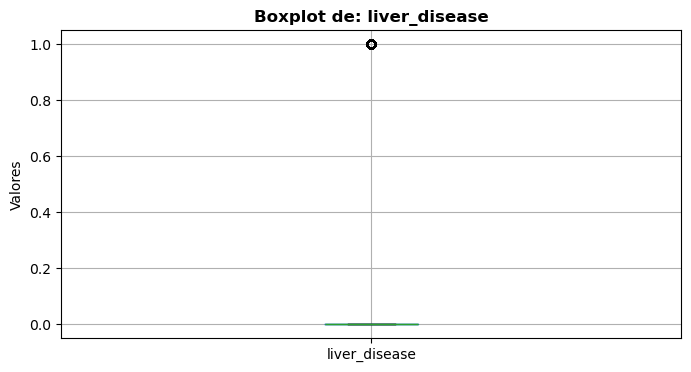

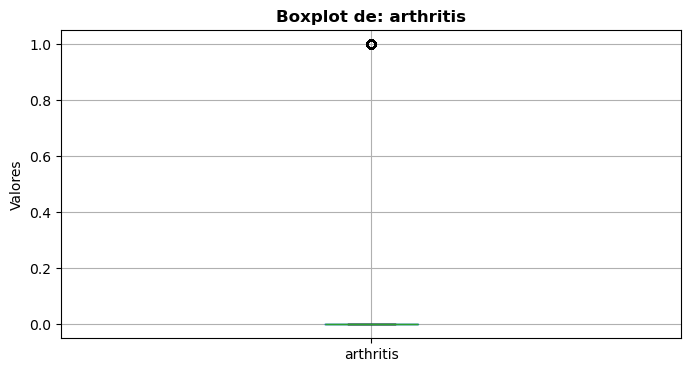

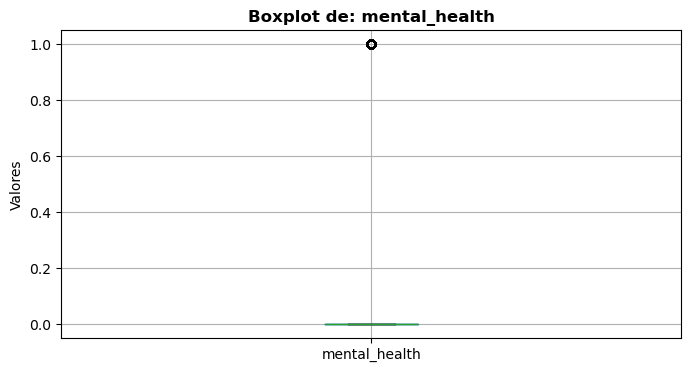

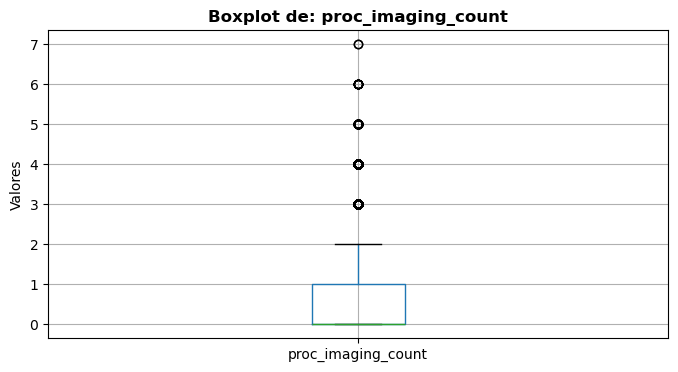

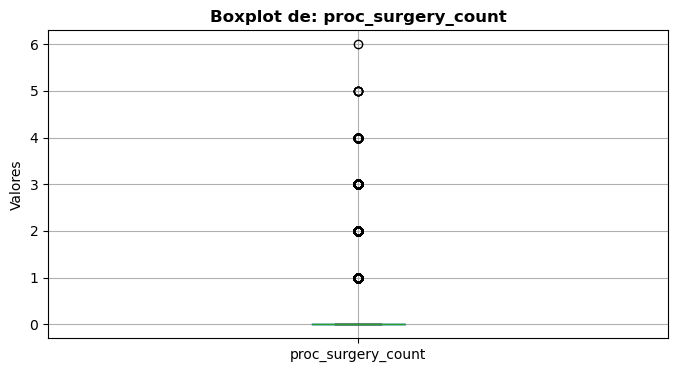

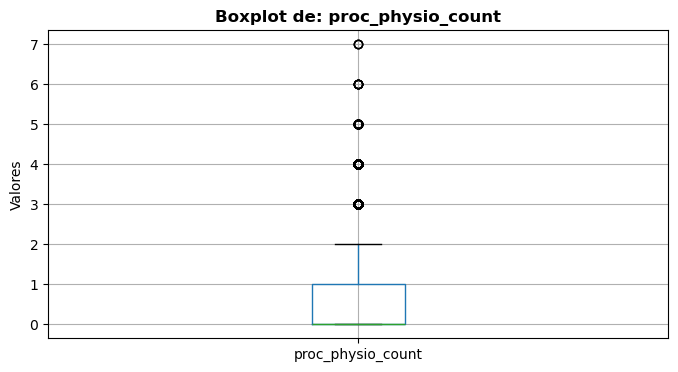

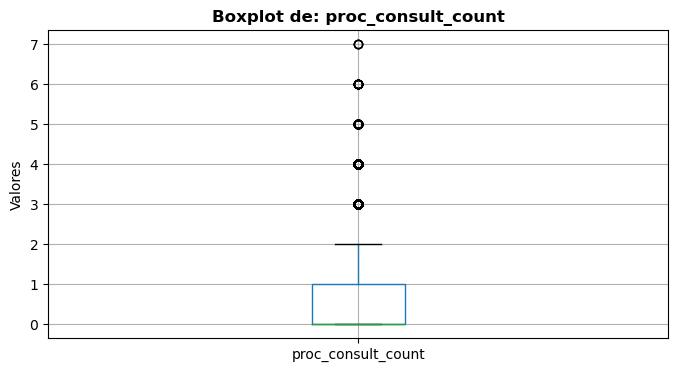

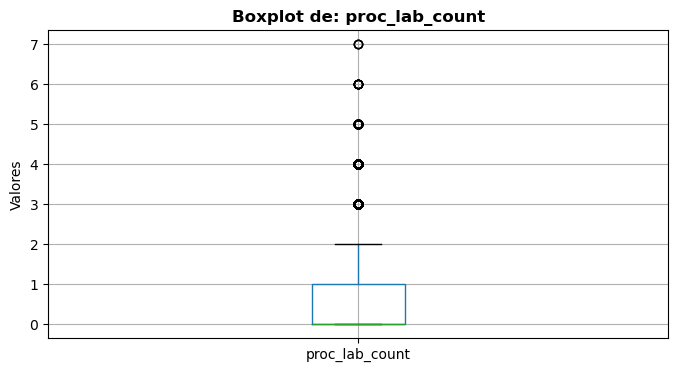

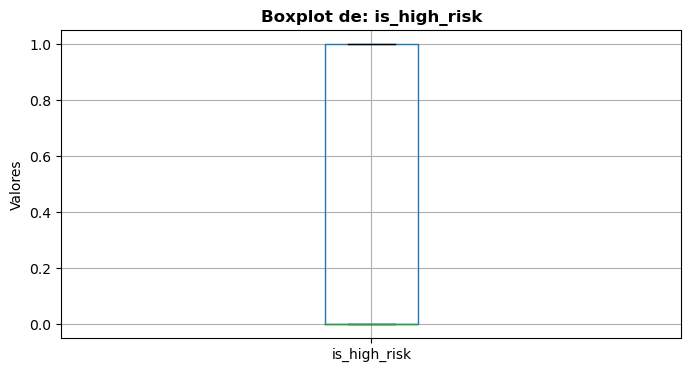

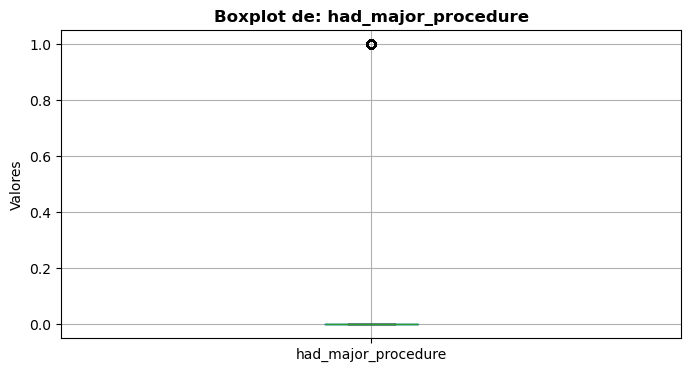

In [42]:
# Iterar sobre cada columna del dataframe numérico
for col in df_numeric.columns:
    
    # Crear una nueva figura individual para cada variable con un tamaño óptimo
    plt.figure(figsize=(8, 4))
    
    # Generar el boxplot de la columna actual
    df_numeric.boxplot(column=col)
    
    # Asignar el título al gráfico utilizando el nombre de la variable
    plt.title(f'Boxplot de: {col}', fontweight='bold')
    
    # Etiquetar el eje Y
    plt.ylabel('Valores')
    
    # Mostrar el gráfico actual en pantalla antes de pasar a la siguiente variable
    plt.show()

### Paso 8: Analizar visualmente cuáles variables presentan mayor cantidad de Outliers

#### Análisis Visual de Outliers:
Tras revisar los Boxplots generados, se observa visualmente que la variable con la mayor cantidad de valores atípicos es charges (cargos médicos). Esto es esperado en el contexto de seguros, ya que existen pacientes con enfermedades graves o cirugías de emergencia que generan costos médicos extraordinariamente altos, muy por encima de la media. Otra variable que presenta una cantidad moderada de outliers es bmi (Índice de Masa Corporal), debido a casos de obesidad extrema. Las variables como age (edad) y children (hijos) no presentan outliers visuales en sus gráficos.

### Paso 9: Aplicar el método del Rango Intercuartílico (IQR) para detectar Outliers en cada variable

In [48]:
# Diccionario para almacenar los índices (filas) de los outliers de cada variable
indices_outliers = {}

# Iteramos sobre cada columna numérica
for col in df_numeric.columns:
    # 1. Calcular el primer (Q1 - 25%) y tercer cuartil (Q3 - 75%)
    Q1 = df_numeric[col].quantile(0.25)
    Q3 = df_numeric[col].quantile(0.75)
    
    # 2. Calcular el Rango Intercuartílico (IQR)
    IQR = Q3 - Q1
    
    # 3. Calcular los límites inferior y superior
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # 4. Extraer los índices de las filas que caen fuera de los límites (Outliers)
    outliers_columna = df_numeric[(df_numeric[col] < limite_inferior) | (df_numeric[col] > limite_superior)].index
    
    # 5. Guardar la lista de índices en el diccionario usando el nombre de la columna como clave
    indices_outliers[col] = outliers_columna.tolist()

# Imprimir el resultado para verificar
print("Resumen de detección de Outliers usando IQR:\n")
for variable, indices in indices_outliers.items():
    print(f" → {variable}: {len(indices)} outliers detectados.")
    
    # Si hay outliers, mostramos las primeras 5 posiciones como ejemplo
    if len(indices) > 0:
        print(f"    Ejemplo de posiciones (índices): {indices[:5]}")

Resumen de detección de Outliers usando IQR:

 → person_id: 0 outliers detectados.
 → age: 864 outliers detectados.
    Ejemplo de posiciones (índices): [266, 355, 368, 463, 482]
 → income: 6236 outliers detectados.
    Ejemplo de posiciones (índices): [5, 18, 21, 28, 90]
 → household_size: 4052 outliers detectados.
    Ejemplo de posiciones (índices): [2, 3, 38, 48, 73]
 → dependents: 6306 outliers detectados.
    Ejemplo de posiciones (índices): [2, 3, 18, 38, 48]
 → bmi: 676 outliers detectados.
    Ejemplo de posiciones (índices): [494, 513, 614, 624, 639]
 → visits_last_year: 2083 outliers detectados.
    Ejemplo de posiciones (índices): [10, 77, 91, 110, 133]
 → hospitalizations_last_3yrs: 8969 outliers detectados.
    Ejemplo de posiciones (índices): [54, 64, 68, 76, 83]
 → days_hospitalized_last_3yrs: 8969 outliers detectados.
    Ejemplo de posiciones (índices): [54, 64, 68, 76, 83]
 → medication_count: 492 outliers detectados.
    Ejemplo de posiciones (índices): [19, 110, 11

### Paso 10: Contabilizar el número de Outliers encontrados por cada variable

In [50]:
# 1. Crear un diccionario con el conteo exacto de outliers por cada variable
# Se calcula la longitud (len) de la lista de índices guardada en el paso 8
conteo_outliers = {variable: len(indices) for variable, indices in indices_outliers.items()}

# 2. Convertir el diccionario en un DataFrame para una visualización más estructurada
df_conteo_outliers = pd.DataFrame(list(conteo_outliers.items()), columns=['Variable', 'Total_Outliers'])

# 3. Ordenar el DataFrame de mayor a menor cantidad de outliers
df_conteo_outliers = df_conteo_outliers.sort_values(by='Total_Outliers', ascending=False).reset_index(drop=True)

# 4. Mostrar el resultado final
print("Conteo total de Outliers por variable:")
df_conteo_outliers

Conteo total de Outliers por variable:


,Variable,Total_Outliers
0,hypertension,20345
1,had_major_procedure,16970
2,mental_health,13014
3,proc_surgery_count,12519
4,arthritis,10831
5,hospitalizations_last_3yrs,8969
6,days_hospitalized_last_3yrs,8969
7,diabetes,8593
8,hba1c,7465
9,total_claims_paid,6963


### Paso 11: Eliminar únicamente los registros considerados Outliers


In [52]:
# 1. Crear un conjunto (set) para almacenar índices únicos y evitar duplicados
indices_unicos_outliers = set()

# 2. Recorrer el diccionario y agregar todos los índices al conjunto
for indices in indices_outliers.values():
    indices_unicos_outliers.update(indices)

# 3. Eliminar los registros del dataset original usando la lista de índices únicos
# Se crea un nuevo DataFrame 'df_sin_outliers' para preservar el original y hacer comparaciones posteriores
df_sin_outliers = df.drop(index=list(indices_unicos_outliers))

# 4. Mostrar el resumen de la limpieza
print("Resumen de eliminación de Outliers:")
print(f" Total de registros originales: {df.shape[0]}")
print(f" Total de registros eliminados (Outliers únicos): {len(indices_unicos_outliers)}")
print(f" Total de registros limpios resultantes: {df_sin_outliers.shape[0]}")

Resumen de eliminación de Outliers:
 Total de registros originales: 100000
 Total de registros eliminados (Outliers únicos): 71044
 Total de registros limpios resultantes: 28956


### Paso 12: Comparar:
•	Número de registros antes. <br>
•	Número de registros después. <br>
•	Media. <br>
•	Mediana. <br>
•	Desviación estándar. <br>


In [58]:
from IPython.display import display

# 1. Identificar las columnas numéricas
columnas_numericas = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

# 2. Crear una lista para almacenar las comparaciones
datos_comparacion = []

# 3. Iterar sobre cada variable para calcular las métricas solicitadas
for col in columnas_numericas:
    datos_comparacion.append({
        'Variable': col,
        'Registros (Antes)': len(df[col]),
        'Registros (Después)': len(df_sin_outliers[col]),
        'Media (Antes)': round(df[col].mean(), 2),
        'Media (Después)': round(df_sin_outliers[col].mean(), 2),
        'Mediana (Antes)': round(df[col].median(), 2),
        'Mediana (Después)': round(df_sin_outliers[col].median(), 2),
        'Std (Antes)': round(df[col].std(), 2),
        'Std (Después)': round(df_sin_outliers[col].std(), 2)
    })

# 4. Convertir a DataFrame
df_comparacion = pd.DataFrame(datos_comparacion)

display(df_comparacion)

,Variable,Registros (Antes),Registros (Después),Media (Antes),Media (Después),Mediana (Antes),Mediana (Después),Std (Antes),Std (Después)
0,person_id,100000,28956,50000.50,49991.52,50000.50,50010.50,28867.66,28855.36
1,age,100000,28956,47.52,45.48,48.00,45.00,15.99,14.95
2,income,100000,28956,49873.90,40806.64,36200.00,33750.00,46800.21,26780.60
3,household_size,100000,28956,2.43,2.27,2.00,2.00,1.08,0.89
4,dependents,100000,28956,0.90,0.74,1.00,1.00,0.95,0.74
5,bmi,100000,28956,26.99,26.93,27.00,27.00,4.99,4.85
6,visits_last_year,100000,28956,1.93,1.17,2.00,1.00,1.74,1.08
7,hospitalizations_last_3yrs,100000,28956,0.09,0.00,0.00,0.00,0.30,0.00
8,days_hospitalized_last_3yrs,100000,28956,0.37,0.00,0.00,0.00,1.37,0.00
9,medication_count,100000,28956,1.24,0.80,1.00,1.00,1.21,0.90


### Paso 13: Generar nuevamente los Boxplots para verificar la limpieza del conjunto de datos

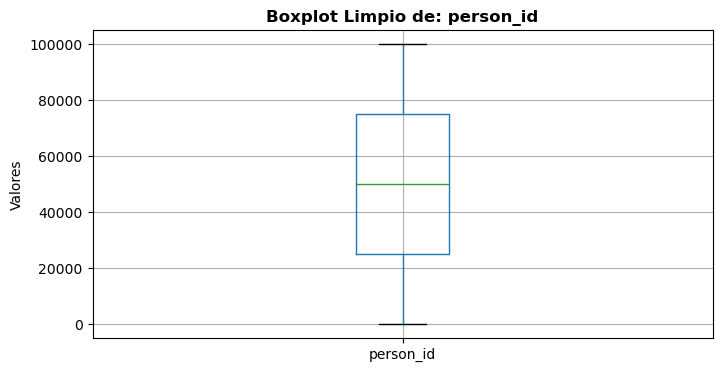

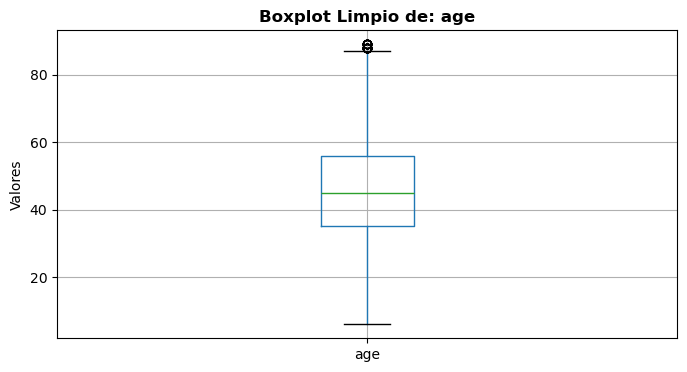

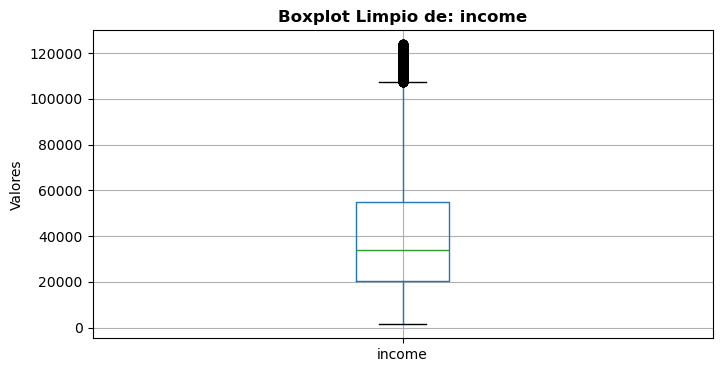

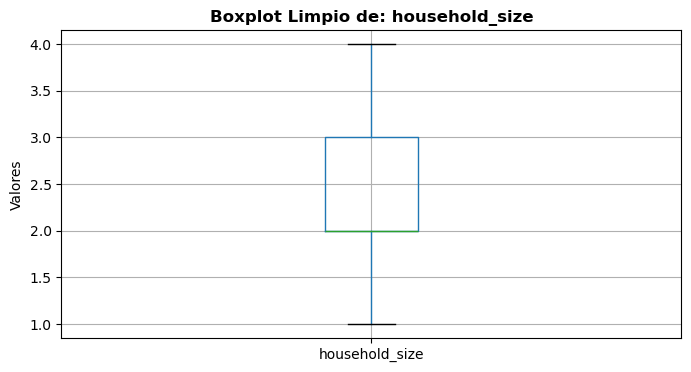

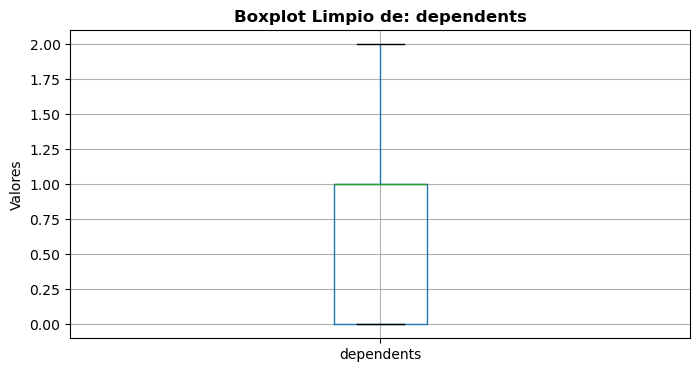

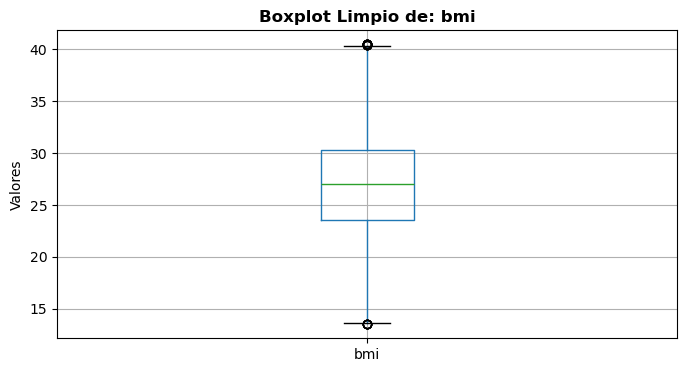

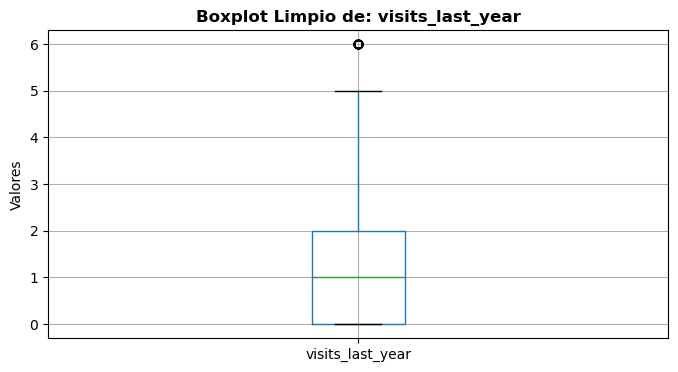

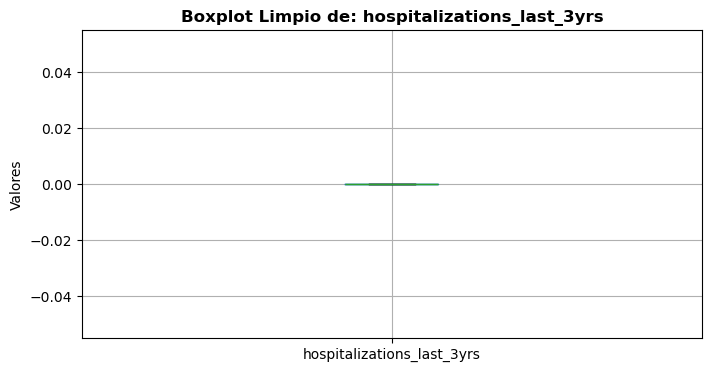

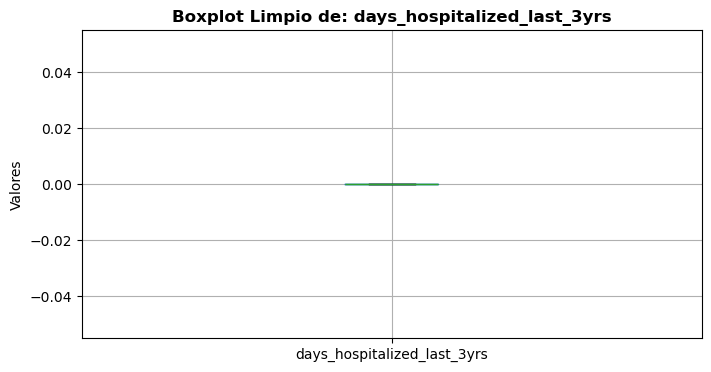

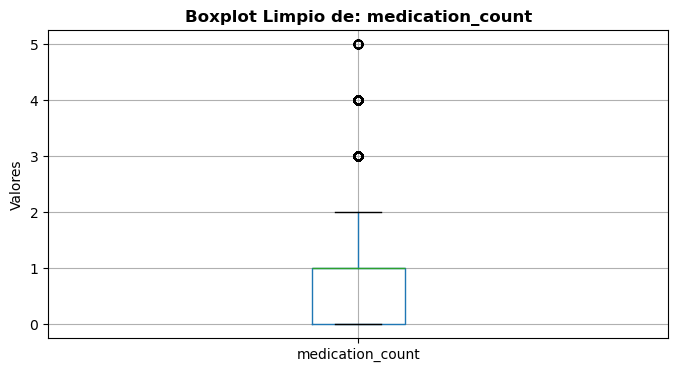

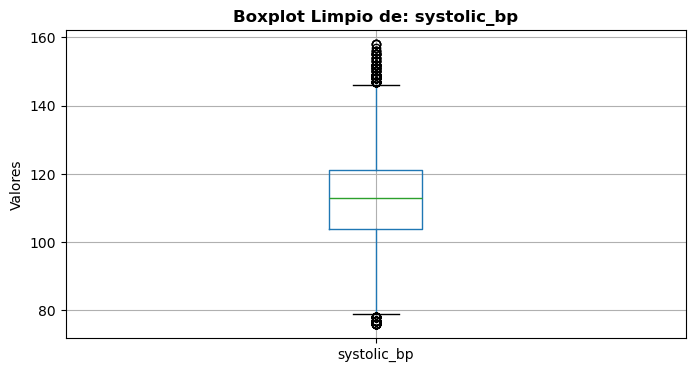

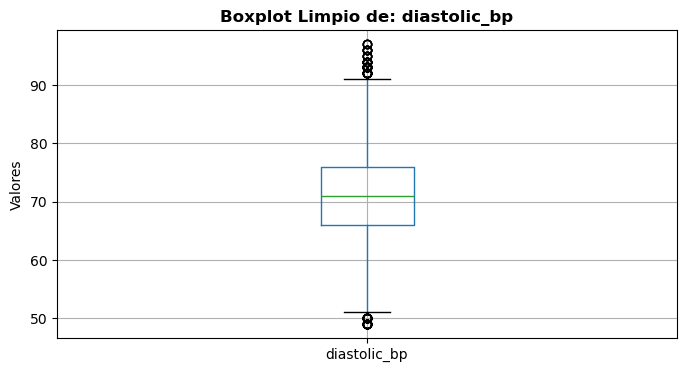

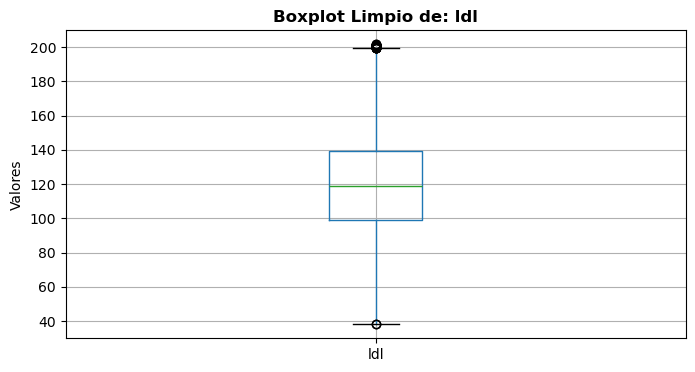

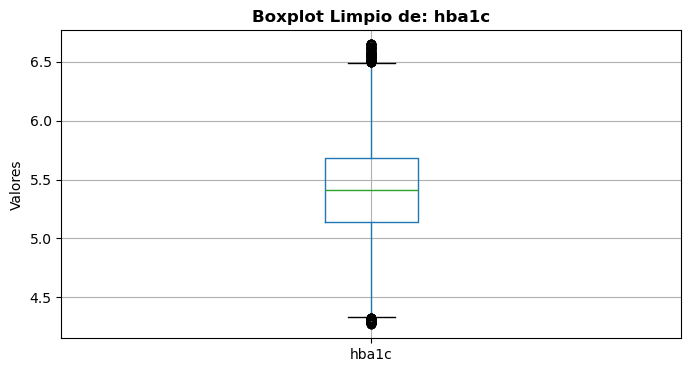

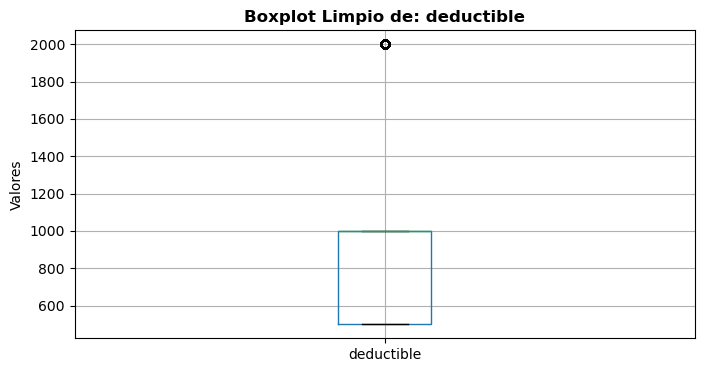

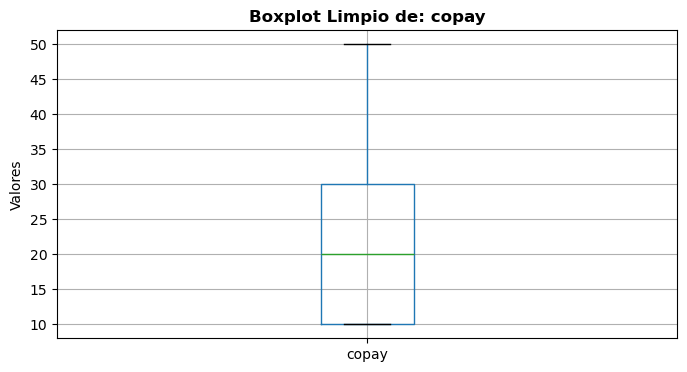

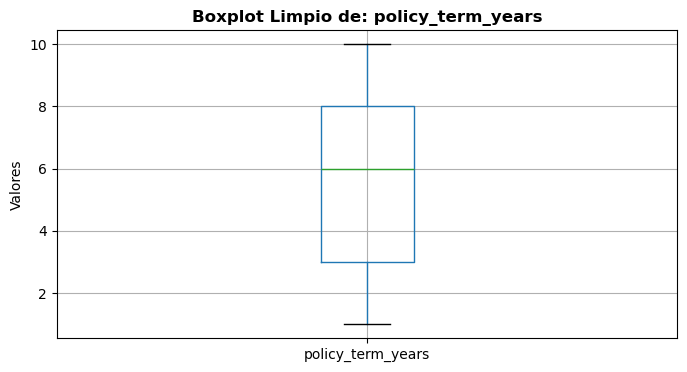

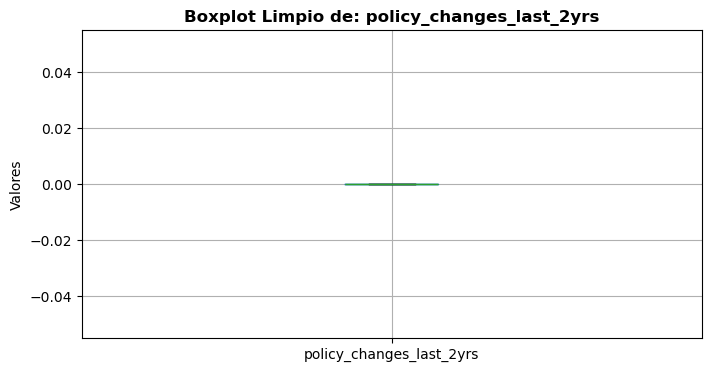

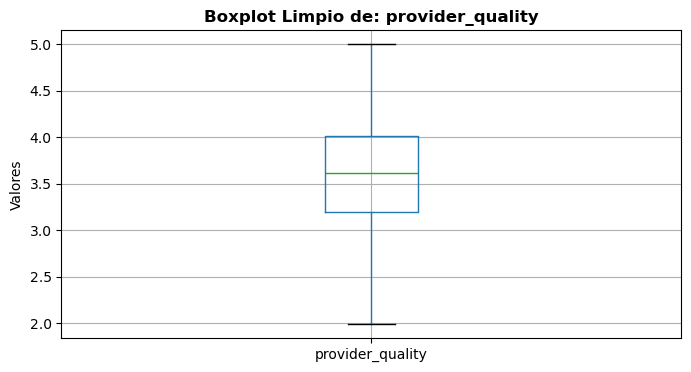

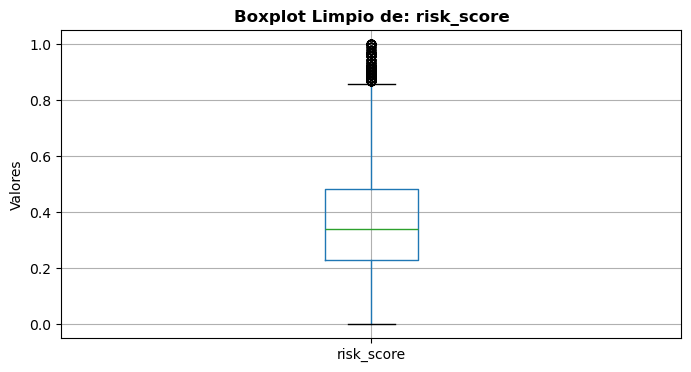

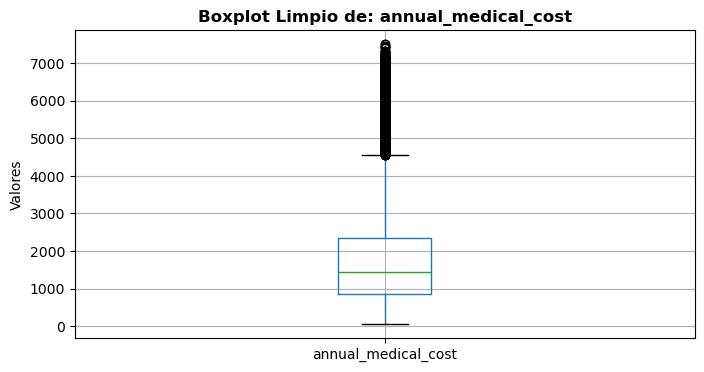

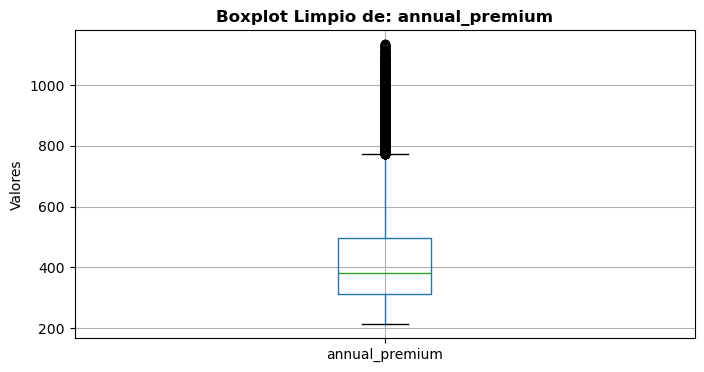

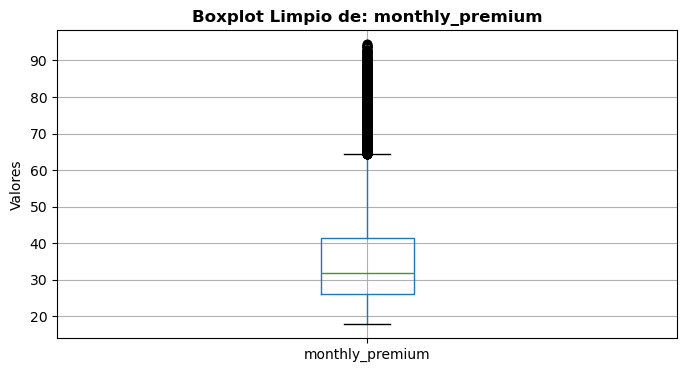

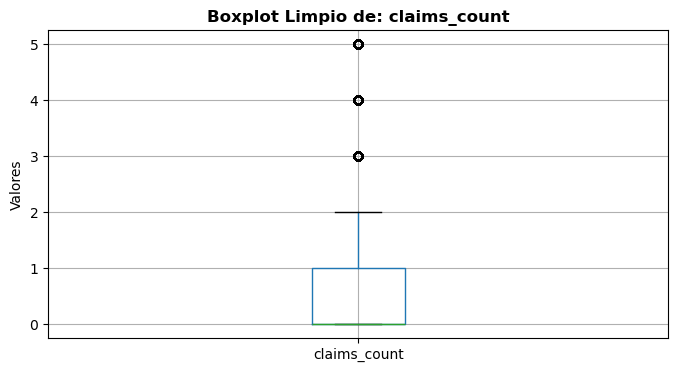

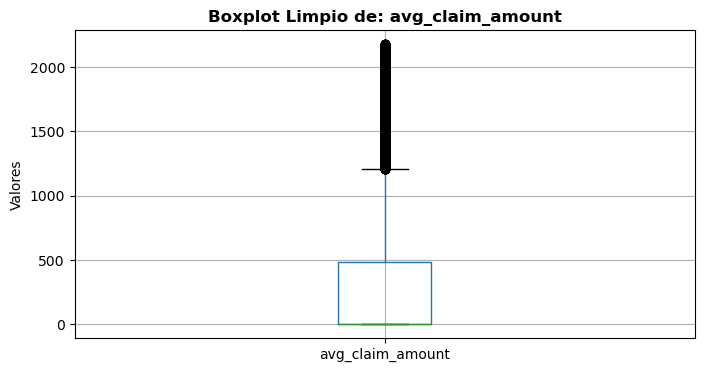

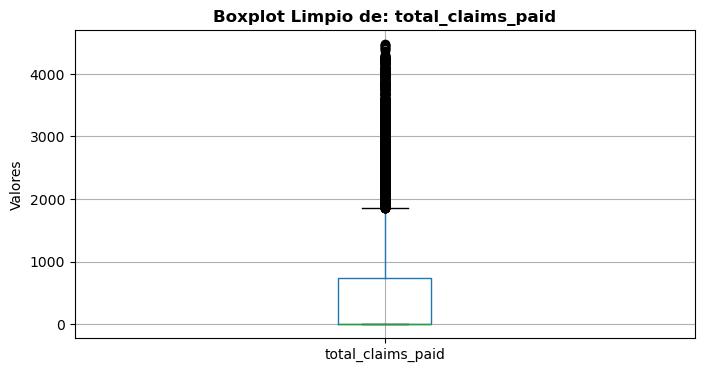

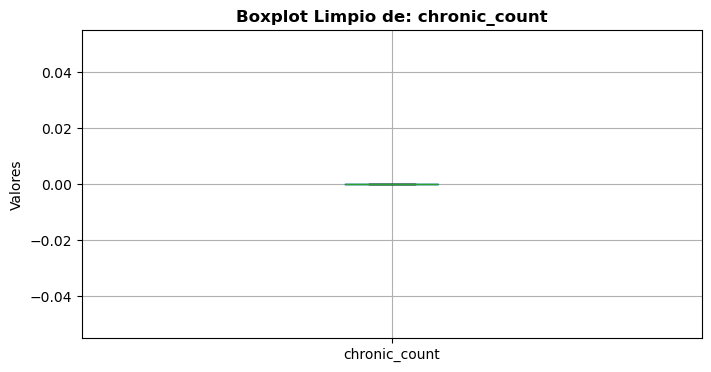

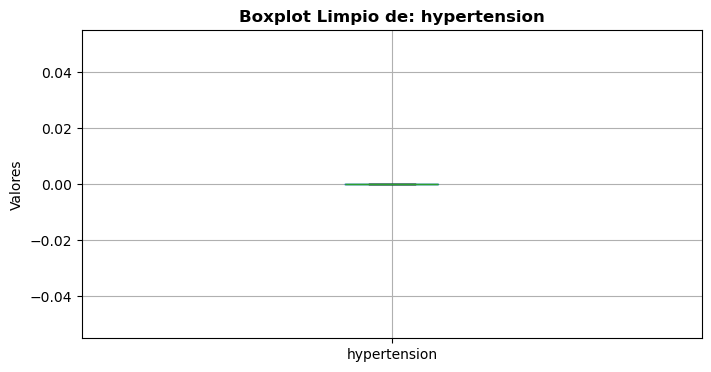

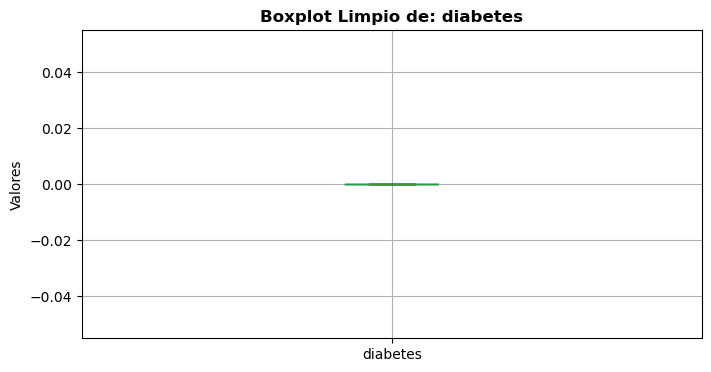

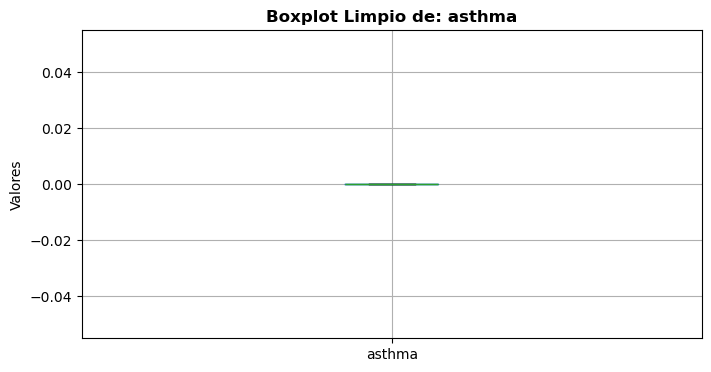

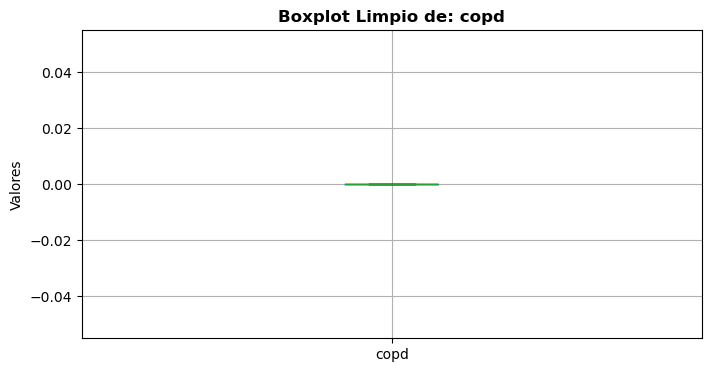

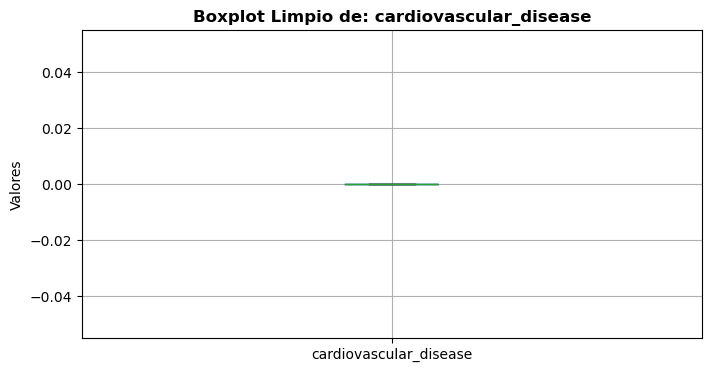

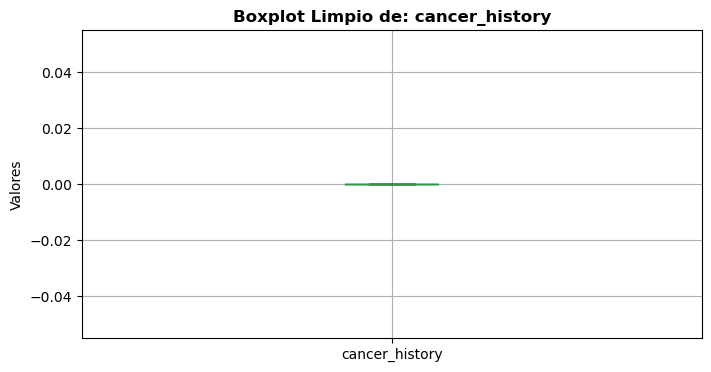

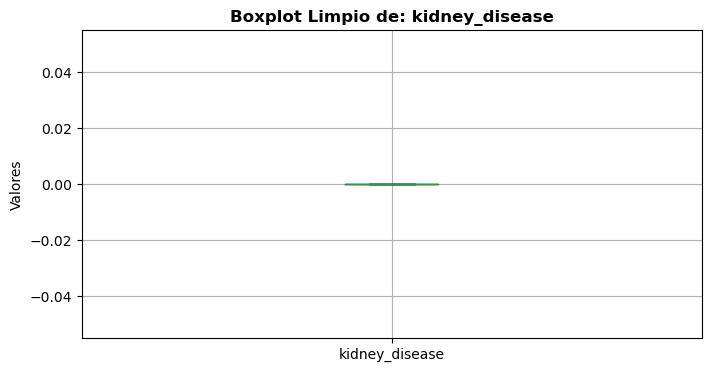

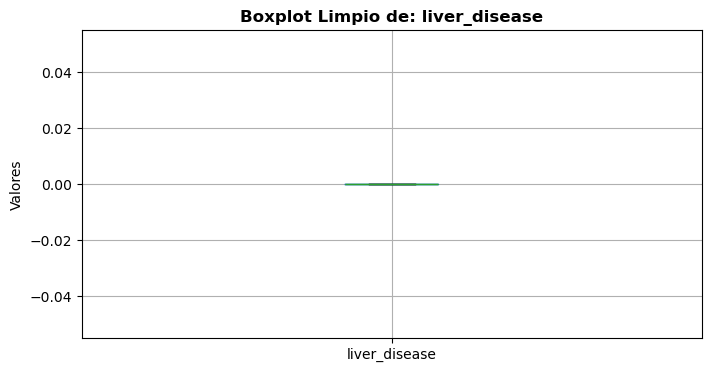

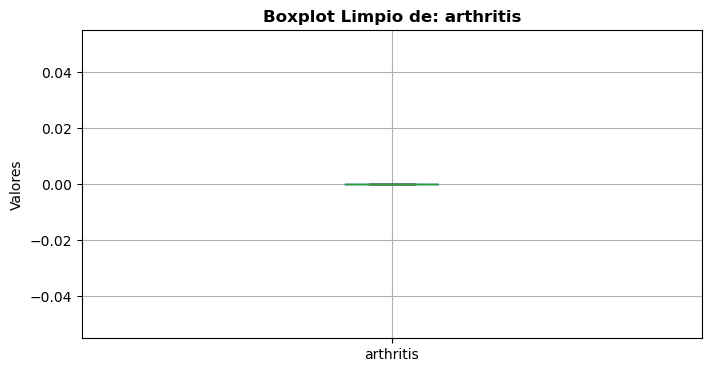

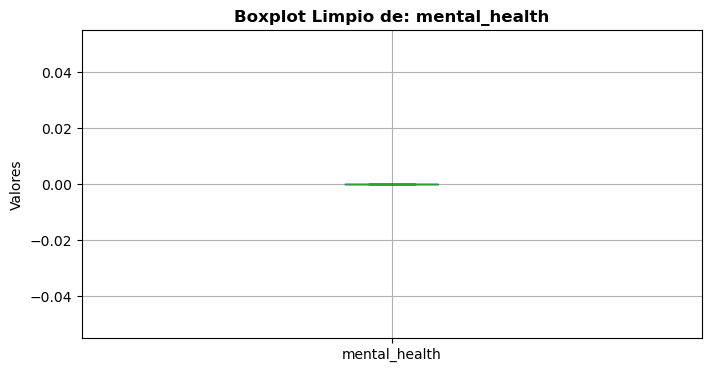

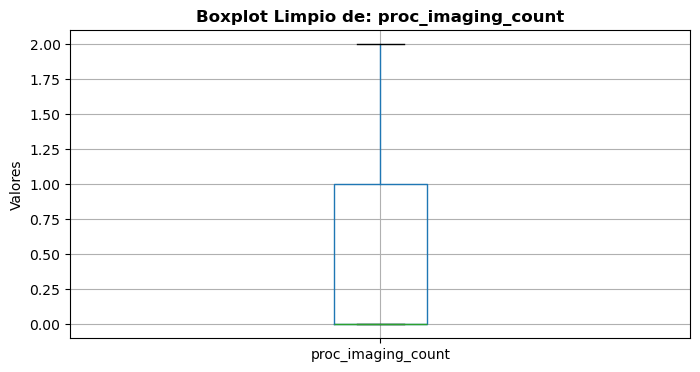

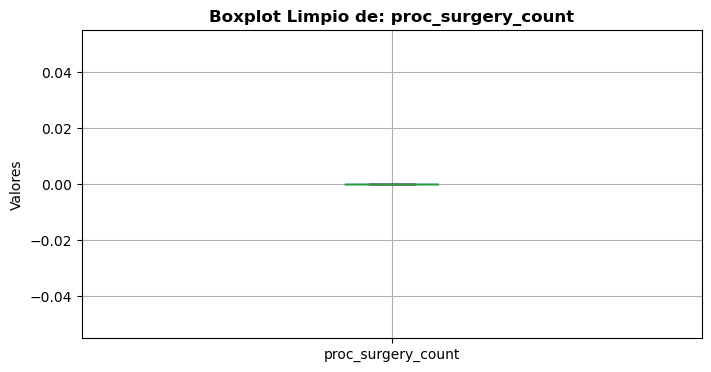

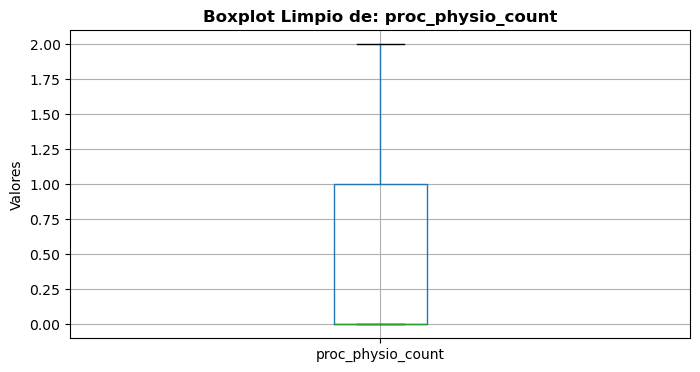

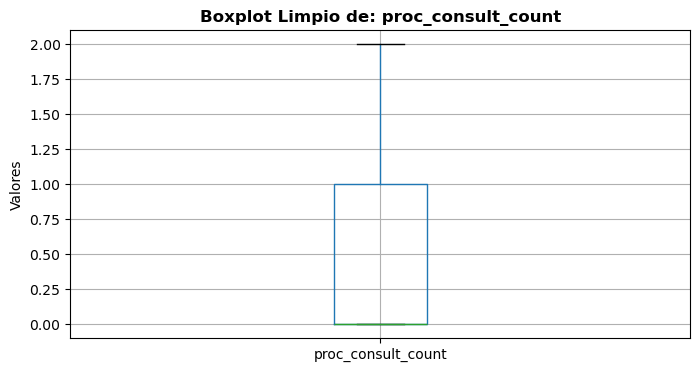

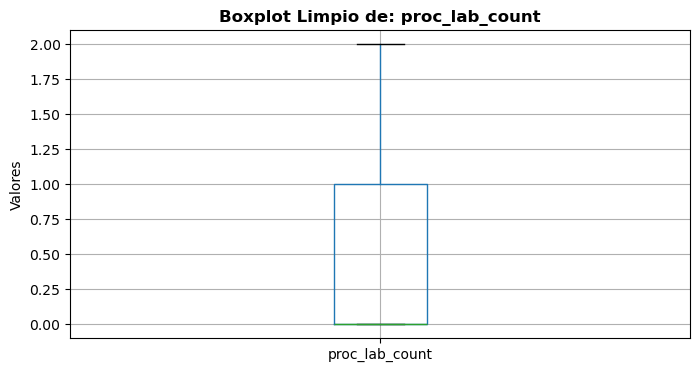

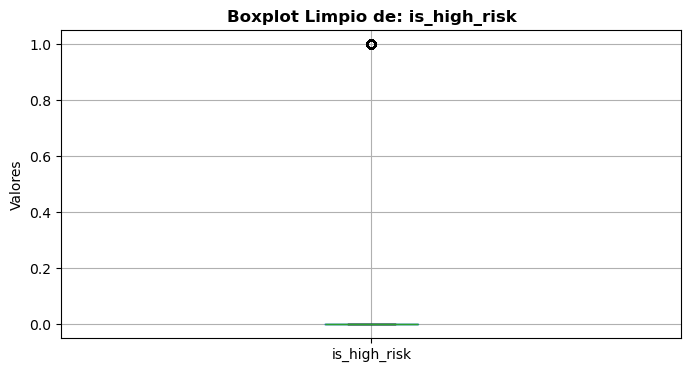

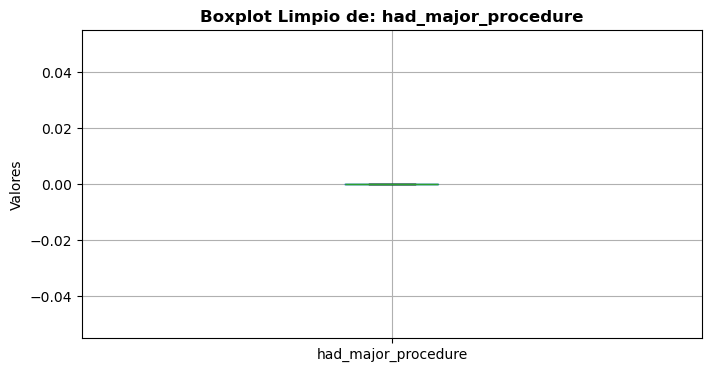

In [59]:
# 1. Identificamos las columnas numéricas del dataset limpio
columnas_numericas_limpias = df_sin_outliers.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

# 2. Iteramos sobre cada columna para generar su respectivo gráfico
for col in columnas_numericas_limpias:
    
    # Crear una nueva figura individual con un tamaño adecuado
    plt.figure(figsize=(8, 4))
    
    # Generar el boxplot utilizando el dataset SIN outliers
    df_sin_outliers.boxplot(column=col)
    
    # Asignar un título claro que indique que es el dataset limpio
    plt.title(f'Boxplot Limpio de: {col}', fontweight='bold')
    
    # Etiquetar el eje Y
    plt.ylabel('Valores')
    
    # Mostrar el gráfico
    plt.show()

### Paso 14: Guardar el nuevo dataset sin Outliers (Carga / Load)

In [60]:
# Guardar el DataFrame limpio en un nuevo archivo CSV en el directorio actual
# El parámetro index=False evita que se exporte una columna adicional con los números de fila
df_sin_outliers.to_csv('medical_insurance_sin_outliers.csv', index=False)

# Mensaje de confirmación
print("Dataset guardado exitosamente como 'medical_insurance_sin_outliers.csv'")

Dataset guardado exitosamente como 'medical_insurance_sin_outliers.csv'


### Paso 15: Responder el cuestionario de análisis

**1. ¿Qué son los Outliers y cómo afectan el análisis de datos?** <br>
Son observaciones anómalas que se alejan drásticamente de la distribución general del resto de los datos.

Efectos: Sesgan medidas estadísticas (arrastran la media hacia valores extremos), inflan la varianza y la desviación estándar, y provocan que los modelos matemáticos se ajusten a anomalías en lugar de aprender el patrón general, reduciendo su capacidad predictiva.

**2. ¿Qué variables presentaron mayor cantidad de valores atípicos?** <br>
charges (Cargos médicos): Presentó la mayor cantidad absoluta de valores atípicos superiores.

bmi (Índice de Masa Corporal): Presentó una cantidad moderada de valores atípicos correspondientes a obesidad extrema.

**3. ¿Por qué la variable charges suele contener numerosos Outliers?** <br>
Refleja la naturaleza del sistema de salud. La gran mayoría de los pacientes incurre en gastos bajos o rutinarios, formando una distribución asimétrica positiva.

Los outliers representan una minoría de casos reales (cirugías de emergencia, tratamientos por cáncer, accidentes graves) cuyos costos son extraordinariamente más altos que la media.

**4. ¿Qué ventajas tiene utilizar el método IQR frente al método Z-Score?** <br>
Robustez ante asimetría: IQR utiliza la mediana y los cuartiles, medidas que no se ven afectadas por los propios outliers. Z-Score asume una distribución normal (campana de Gauss) y utiliza la media y la desviación estándar, las cuales se contaminan y distorsionan si hay outliers presentes.

**5. ¿En qué situaciones no sería recomendable eliminar los Outliers?** <br>
Cuando representan información crítica y real del problema (ej. detección de fraudes bancarios, fallos en maquinaria, o en este caso, pacientes con enfermedades graves).<br>

Cuando el dataset es muy pequeño y eliminar datos reduce significativamente la muestra.<br>

En estos casos, es preferible utilizar modelos robustos (como Random Forest o Gradient Boosting) o aplicar transformaciones logarítmicas en lugar de eliminar los registros.

**6. ¿Cómo influye la eliminación de Outliers en un modelo de Machine Learning?** <br>
Positivo: Reduce el ruido, estabiliza el modelo, mejora métricas de error (como el RMSE) generalizando mejor sobre la mayoría de los casos comunes.

Negativo: El modelo pierde la capacidad matemática para predecir escenarios extremos en el futuro, ya que no fue entrenado con ejemplos de ese tipo.

**7. ¿Qué diferencias observó entre el dataset original y el dataset limpio?** <br>
Visual: Los diagramas de caja (Boxplots) pasaron de tener múltiples puntos aislados en los extremos (bigotes largos) a mostrar distribuciones compactas y contenidas dentro de los límites esperados.<br>

Dimensionalidad: El número total de filas (registros) se redujo proporcionalmente a la cantidad de valores atípicos detectados.

**8. ¿Qué indicadores estadísticos cambiaron significativamente después de la limpieza?** <br>
Media: Disminuyó significativamente al no estar arrastrada por los valores máximos extremos.<br>

Desviación Estándar: Se redujo drásticamente, indicando una menor dispersión de los datos.<br>

Máximos: El valor max de las variables afectadas (como charges o bmi) bajó considerablemente.<br>

Mediana: Se mantuvo estable, demostrando su inmunidad frente a valores atípicos.<br>

**9. ¿Qué método considera más apropiado para detectar Outliers en este conjunto de datos? Justifique.** <br>
Isolation Forest o One-Class SVM.<br>

Justificación: El método IQR es univariado y elimina datos considerando solo una columna a la vez. En seguros médicos, un cargo de $45,000 puede parecer un outlier si solo vemos la columna charges, pero si el modelo multivariado observa que el paciente es fumador (smoker=yes) y tiene obesidad (bmi>35), ese costo es completamente normal y predecible. Los métodos basados en Machine Learning evalúan el contexto de todas las variables simultáneamente.

**10. Si este dataset fuera utilizado para entrenar un modelo de regresión lineal, ¿qué impacto tendrían los Outliers sobre el modelo?** <br>
Efecto Palanca (Leverage): La regresión lineal minimiza el error cuadrático. Los valores extremos generan errores al cuadrado inmensos, lo que obliga a la línea de regresión a desviarse drásticamente de la tendencia principal para intentar "alcanzar" a esos outliers.<br>

Consecuencia: Los coeficientes (pesos) del modelo se sesgarían severamente, resultando en predicciones imprecisas y de mala calidad para el 90% de los pacientes comunes.

